<a href="https://colab.research.google.com/github/AnnaZapototska/goit-colab-homeworks/blob/development/hw_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task

In [ ]:
!ls

sample_data


In [ ]:
!pip install -U gym
!pip install numpy==1.23.5

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 721.7/721.7 kB 13.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for gym: filename=gym-0.26.2-py3-none-any.whl size=827728 sha256=56e28302281eb93f92958f553e1e0224d1354f2e47ad0f96bdd8c5f18e574c46
  Stored in directory: /root/.cache/pip/wheels/95/51/6c/9bb05ebbe7c5cb8171dfaa3611f32622ca4658d53f31c79077
Successfully built gym
  Attempting uninstall: gym
    Found existing installation: gym 0.25.2
    Uninstalling gym-0.25.2:
      Successfully uninstalled gym-0.25.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 85.5 MB/s eta 0:00:00
  Installing build dep

In [ ]:
!git clone https://github.com/SasankYadati/FrozenLake-DP.git FrozenLakeDP
!pip install gymnasium

fatal: destination path 'FrozenLakeDP' already exists and is not an empty directory.


In [ ]:
import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np

from FrozenLakeDP.MarkovDecisionProcess import MarkovDecisionProcess as MDP
from FrozenLakeDP.Agent import Agent

plt.style.use("dark_background")

env = gym.make(
    "FrozenLake-v1",
    is_slippery=True,
    render_mode="rgb_array"
)

obs, info = env.reset()

mdp = MDP(
    env.observation_space.n,
    env.action_space.n,
    env.unwrapped.P
)

In [ ]:
def show_render(img):
    import matplotlib.pyplot as plt


    if isinstance(img, list):
        for frame in img:
            plt.imshow(frame)
            plt.axis('off')
            plt.show()
    else:
        plt.imshow(img)
        plt.axis('off')
        plt.show()

In [ ]:
def extract_policy(value_table, gamma):

    policy = np.zeros(env.observation_space.n)

    for state in range(env.observation_space.n):
        Q_table = np.zeros(env.action_space.n)
        for action in range(env.action_space.n):
            for next_sr in env.unwrapped.P[state][action]:
                trans_prob, next_state, reward_prob, _ = next_sr
                Q_table[action] += (trans_prob * (reward_prob + gamma * value_table[next_state]))

        policy[state] = np.argmax(Q_table)

    return policy

In [ ]:
def compute_value_function(policy, gamma):
    value_table = np.zeros(env.observation_space.n)

    threshold = 1e-10
    no_of_iterations = 100000

    for _ in range(no_of_iterations):

        updated_value_table = np.copy(value_table)
        delta = 0

        for state in range(env.observation_space.n):

            action = int(policy[state])
            old_value = value_table[state]

            value_table[state] = sum(
                trans_prob * (reward + gamma * updated_value_table[next_state])
                for trans_prob, next_state, reward, _ in env.unwrapped.P[state][action]
            )
            delta = max(delta, abs(old_value - value_table[state]))

        if delta < threshold:
          break

    return value_table

In [ ]:
gamma = 1.0

old_policy = np.zeros(env.observation_space.n)

new_value_function = compute_value_function(old_policy, gamma)

In [ ]:
def policy_iteration(gamma):

    old_policy = np.zeros(env.observation_space.n)

    no_of_iterations = 1000

    for i in range(no_of_iterations):

        new_value_function = compute_value_function(old_policy, gamma)

        new_policy = extract_policy(new_value_function, gamma)

        if np.all(old_policy == new_policy):
            print(f"Policy-Iteration converged at step {i+1}.")
            break

        old_policy = np.copy(new_policy)

    return new_policy

In [ ]:
for gamma in [0.5, 0.9, 0.99, 1.0]:
    print(f"\nGamma = {gamma}")
    optimal_policy = policy_iteration(gamma)
    print(optimal_policy)


Gamma = 0.5
Policy-Iteration converged at step 5.
[1. 3. 2. 3. 0. 0. 0. 0. 3. 1. 0. 0. 0. 2. 1. 0.]

Gamma = 0.9
Policy-Iteration converged at step 6.
[0. 3. 0. 3. 0. 0. 0. 0. 3. 1. 0. 0. 0. 2. 1. 0.]

Gamma = 0.99
Policy-Iteration converged at step 7.
[0. 3. 3. 3. 0. 0. 0. 0. 3. 1. 0. 0. 0. 2. 1. 0.]

Gamma = 1.0
Policy-Iteration converged at step 8.
[0. 3. 3. 3. 0. 0. 0. 0. 3. 1. 0. 0. 0. 2. 1. 0.]


In [ ]:
arrows = {
    0: "←",
    1: "↓",
    2: "→",
    3: "↑"
}

for i in range(4):
    row = ""
    for j in range(4):
        state = i * 4 + j
        row += arrows[int(optimal_policy[state])] + " "
    print(row)

← ↑ ↑ ↑ 
← ← ← ← 
↑ ↓ ← ← 
← → ↓ ← 


In [ ]:
for gamma in [0.5, 0.9, 0.99, 1.0]:

    print(f"\n===== Gamma = {gamma} =====")

    optimal_policy = policy_iteration(gamma)

    print("Policy:")
    print(optimal_policy)

    wins = 0

    for _ in range(100):

        observation, info = env.reset()
        done = False

        while not done:
            action = int(optimal_policy[observation])

            observation, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated

        wins += reward

    print(f"Success rate: {wins}%")


===== Gamma = 0.5 =====
Policy-Iteration converged at step 5.
Policy:
[1. 3. 2. 3. 0. 0. 0. 0. 3. 1. 0. 0. 0. 2. 1. 0.]
Success rate: 44%

===== Gamma = 0.9 =====
Policy-Iteration converged at step 6.
Policy:
[0. 3. 0. 3. 0. 0. 0. 0. 3. 1. 0. 0. 0. 2. 1. 0.]
Success rate: 69%

===== Gamma = 0.99 =====
Policy-Iteration converged at step 7.
Policy:
[0. 3. 3. 3. 0. 0. 0. 0. 3. 1. 0. 0. 0. 2. 1. 0.]
Success rate: 72%

===== Gamma = 1.0 =====
Policy-Iteration converged at step 8.
Policy:
[0. 3. 3. 3. 0. 0. 0. 0. 3. 1. 0. 0. 0. 2. 1. 0.]
Success rate: 62%


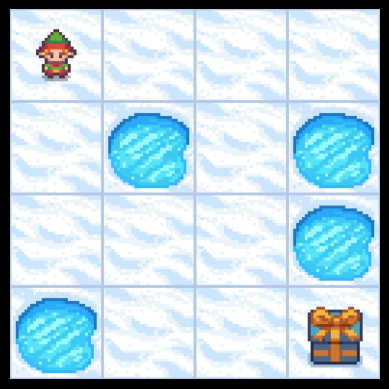

State: 0, Action: 0


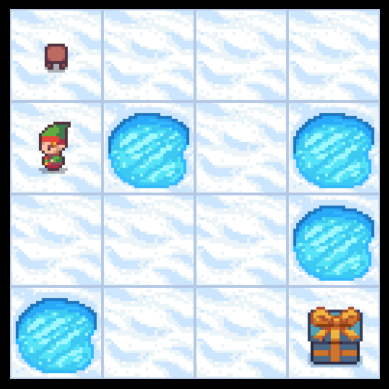

State: 4, Action: 0


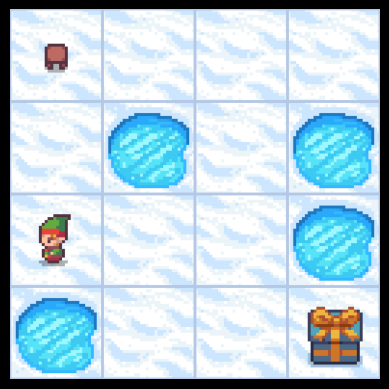

State: 8, Action: 3


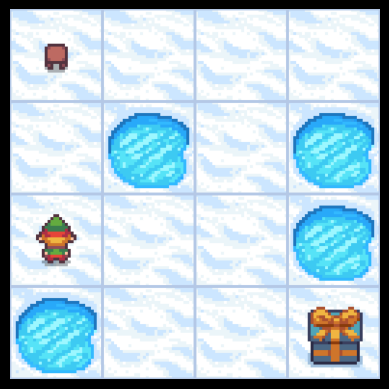

State: 8, Action: 3


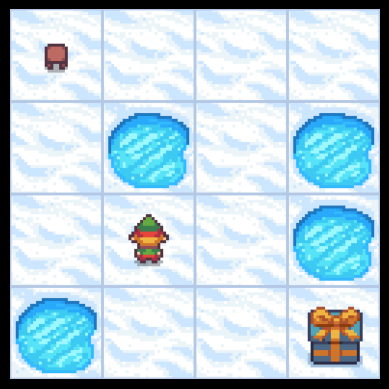

State: 9, Action: 1


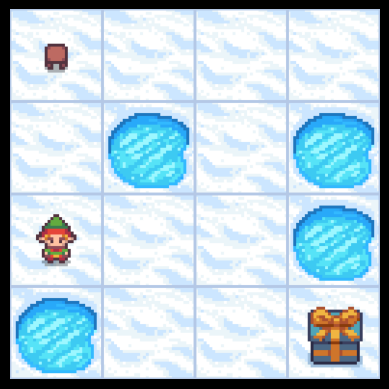

State: 8, Action: 3


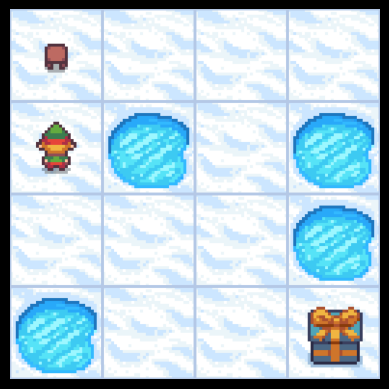

State: 4, Action: 0


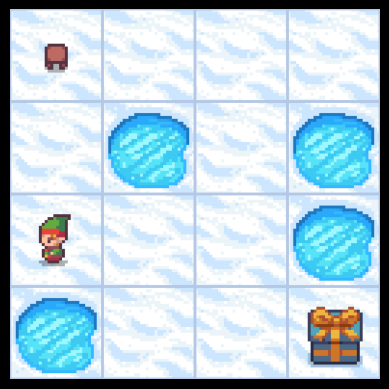

State: 8, Action: 3


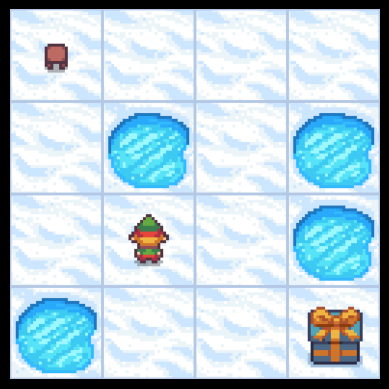

State: 9, Action: 1


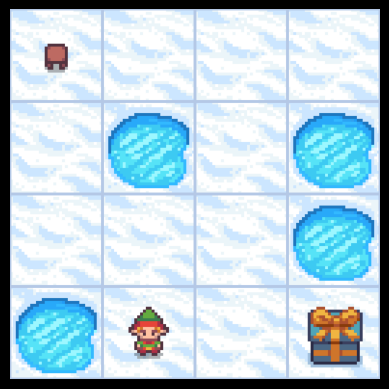

State: 13, Action: 2


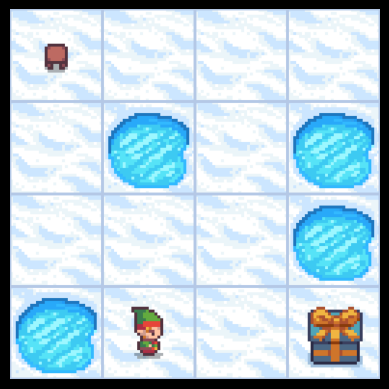

State: 13, Action: 2


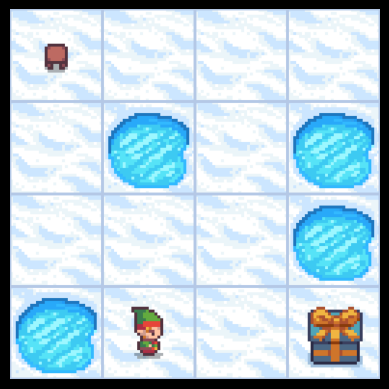

State: 13, Action: 2


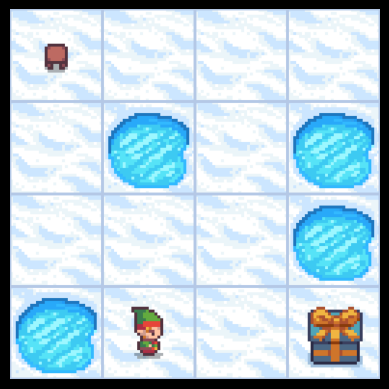

State: 13, Action: 2


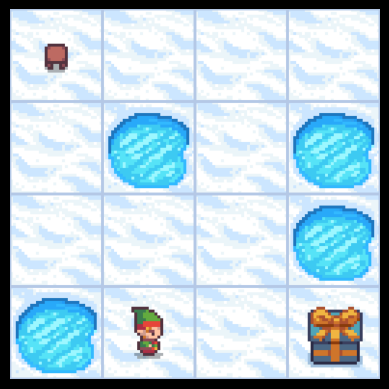

State: 13, Action: 2


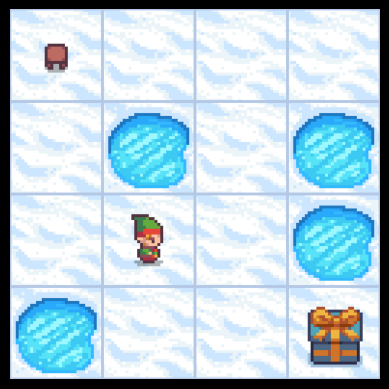

State: 9, Action: 1


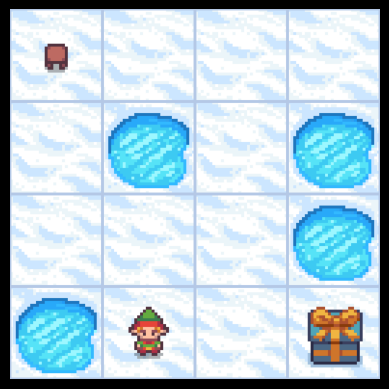

State: 13, Action: 2


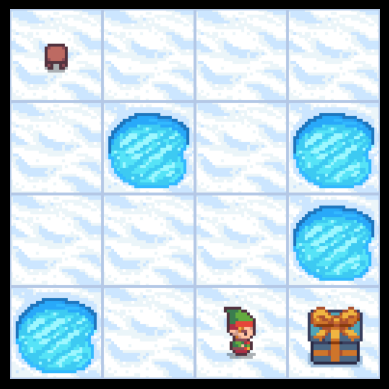

State: 14, Action: 1


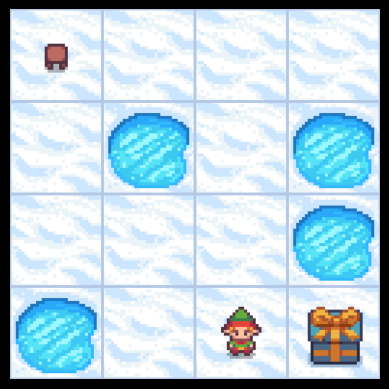

State: 14, Action: 1


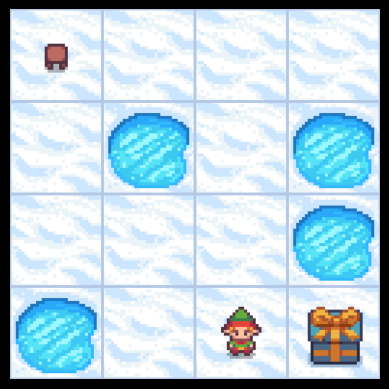

State: 14, Action: 1


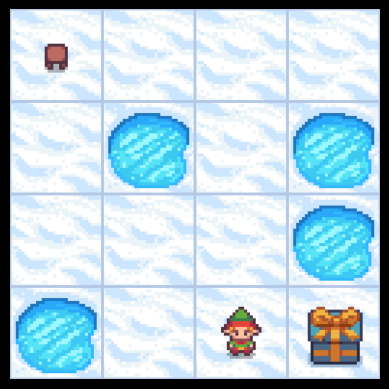

State: 14, Action: 1


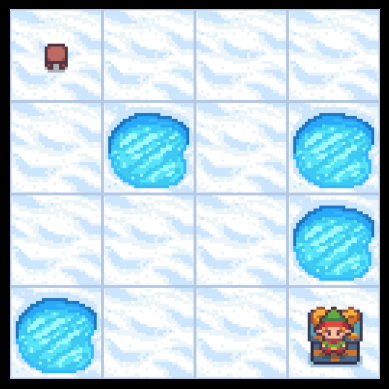

Finished! Reward = 1


In [ ]:
reset_result = env.reset()
observation = reset_result[0] if isinstance(reset_result, tuple) else reset_result

done = False

show_render(env.render())

while not done:
    action = int(optimal_policy[observation])

    print(f"State: {observation}, Action: {action}")

    step_result = env.step(action)

    if len(step_result) == 5:
        observation, reward, terminated, truncated, info = step_result
        done = terminated or truncated
    else:
        observation, reward, done, info = step_result

    show_render(env.render())

print(f"Finished! Reward = {reward}")

# Summary

At a small value of γ (0.5), the agent is more focused on the immediate reward and less concerned with future consequences. At γ=0.99 and γ=1.0, the agent plans the route for a longer period of time, so the policy becomes more cautious. Sometimes the optimal policy suggests moving towards a wall or taking a step that seems illogical. This is due to the fact that the environment is stochastic (is_slippery=True). If the agent tries to move into a wall, then due to randomness it may shift to a safe direction, while moving directly to the goal would have a higher probability of falling into a hole. Thus, the optimal policy maximizes the expected reward, not the length of the route.


In [ ]:
# reset_result = env.reset()
# observation = reset_result[0] if isinstance(reset_result, tuple) else reset_result

# show_render(env.render())

# action = env.action_space.sample()  # Випадкова дія
# print(action)
# step_result = env.step(action)
# if len(step_result) == 5:
#     observation, reward, terminated, truncated, info = step_result
#     done = terminated or truncated
# else:
#     observation, reward, done, info = step_result

# show_render(env.render())

# action = env.action_space.sample()  # Випадкова дія
# print(action)
# step_result = env.step(action)
# if len(step_result) == 5:
#     observation, reward, terminated, truncated, info = step_result
#     done = terminated or truncated
# else:
#     observation, reward, done, info = step_result

# show_render(env.render())

# action = env.action_space.sample()  # Випадкова дія
# print(action)
# step_result = env.step(action)
# if len(step_result) == 5:
#     observation, reward, terminated, truncated, info = step_result
#     done = terminated or truncated
# else:
#     observation, reward, done, info = step_result

# show_render(env.render())


# # # Закриття середовища
# # env.close()